## **Title**

In [1]:
# ==========================================================
# Task 3: Heart Disease Prediction
# Objective:
# Build a machine learning model to predict whether a person
# has heart disease based on medical attributes.
# ==========================================================

## **Import Libraries**

In [2]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## **Load Dataset**

In [4]:
# Load dataset
df = pd.read_csv("heart.csv")

# Display first rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,0,2,145,389,0,1,180,0,0.2,1,2,0,0
1,57,1,0,148,276,1,1,170,0,2.7,1,2,0,0
2,43,1,2,152,399,0,1,183,0,3.3,2,0,0,1
3,71,0,3,178,223,1,1,98,0,2.0,1,0,0,0
4,36,0,3,148,275,1,0,131,1,4.5,1,1,2,1


## **Dataset Overview**

In [5]:
# Dataset information
df.info()

# Summary statistics
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       5000 non-null   int64  
 1   sex       5000 non-null   int64  
 2   cp        5000 non-null   int64  
 3   trestbps  5000 non-null   int64  
 4   chol      5000 non-null   int64  
 5   fbs       5000 non-null   int64  
 6   restecg   5000 non-null   int64  
 7   thalach   5000 non-null   int64  
 8   exang     5000 non-null   int64  
 9   oldpeak   5000 non-null   float64
 10  slope     5000 non-null   int64  
 11  ca        5000 non-null   int64  
 12  thal      5000 non-null   int64  
 13  target    5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54.190600,0.503400,1.466200,144.506600,273.703800,0.50060,0.509000,140.076000,0.492200,3.050360,1.002400,1.509000,0.988200,0.488400
std,14.673109,0.500038,1.117814,31.596513,72.268493,0.50005,0.499969,40.572772,0.499989,1.719913,0.808038,1.107684,0.815471,0.499915
min,29.000000,0.000000,0.000000,90.000000,150.000000,0.00000,0.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,0.000000,0.000000,117.000000,211.000000,0.00000,0.000000,105.000000,0.000000,1.600000,0.000000,1.000000,0.000000,0.000000
50%,54.000000,1.000000,1.000000,144.000000,274.000000,1.00000,1.000000,141.000000,0.000000,3.100000,1.000000,2.000000,1.000000,0.000000
75%,67.000000,1.000000,2.000000,172.000000,336.000000,1.00000,1.000000,175.000000,1.000000,4.500000,2.000000,2.000000,2.000000,1.000000
max,79.000000,1.000000,3.000000,199.000000,399.000000,1.00000,1.000000,209.000000,1.000000,6.000000,2.000000,3.000000,2.000000,1.000000


## **Check Missing Values**

In [6]:
# Check for missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## **Exploratory Data Analysis (EDA)**
## **Heart Disease Distribution**

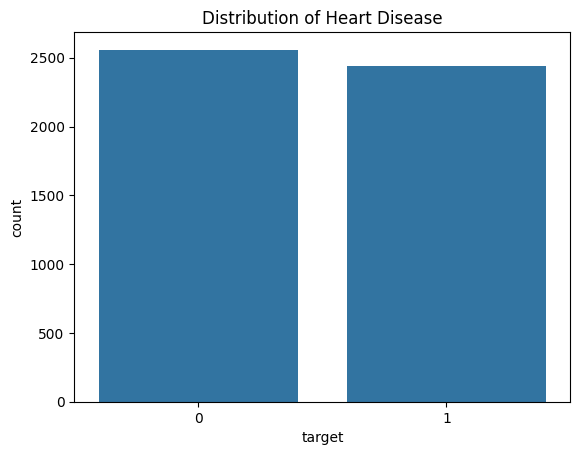

In [7]:
sns.countplot(x="target", data=df)

plt.title("Distribution of Heart Disease")

plt.show()

## **Correlation Heatmap**

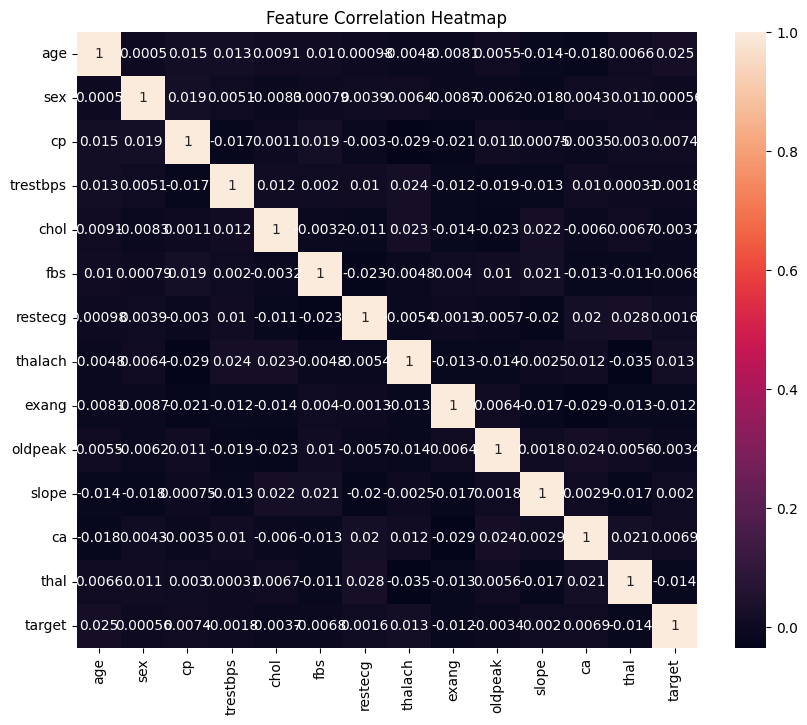

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()

## **Feature Selection**

In [9]:
# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

## **Train Test Split**

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **Train Model**

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## **Predictions**

In [13]:
# Predict test data
y_pred = model.predict(X_test)

## **Accuracy**

In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.495


## **Confusion Matrix**

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[379 121]
 [384 116]]


## **ROC Curve**

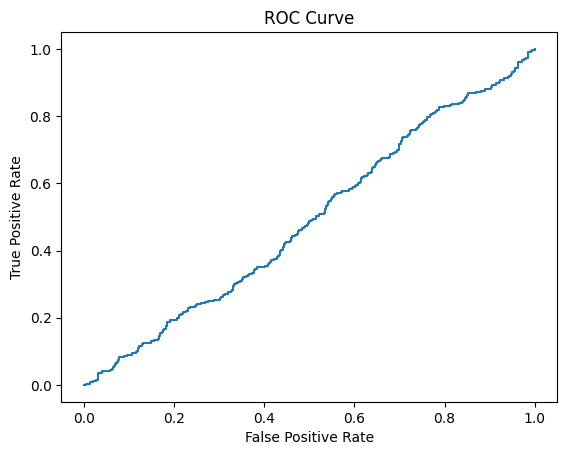

In [16]:
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

## **Feature Importance**

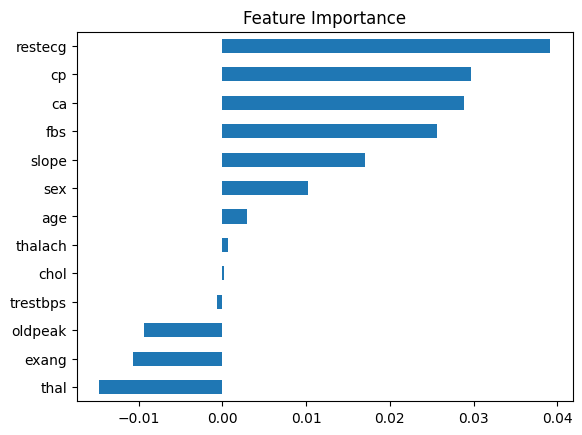

In [19]:
importance = pd.Series(model.coef_[0], index=X.columns)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")

plt.show()

## **Conclusion**

### The logistic regression model was trained to predict heart disease.

### Key Findings:
### 1. The model achieved a reasonable accuracy.
### 2. Some medical attributes show strong correlation with heart disease.
### 3. Feature importance highlights which factors influence predictions most.